<a href="https://colab.research.google.com/github/carlosvint/scrapping--MCIB-B/blob/master/Annomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [1]:
# Upload kaggle.json with the API credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download chethuhn/network-intrusion-dataset

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
100% 230M/230M [00:00<00:00, 275MB/s]



In [3]:
!unzip network-intrusion-dataset.zip

Archive:  network-intrusion-dataset.zip
  inflating: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  
  inflating: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  
  inflating: Friday-WorkingHours-Morning.pcap_ISCX.csv  
  inflating: Monday-WorkingHours.pcap_ISCX.csv  
  inflating: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  
  inflating: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  
  inflating: Tuesday-WorkingHours.pcap_ISCX.csv  
  inflating: Wednesday-workingHours.pcap_ISCX.csv  


In [4]:
# Network Intrusion Detection with PyTorch (Simple Neural Network)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [28]:
# Load the dataset
df1=pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df2=pd.read_csv('Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
df3=pd.read_csv('Friday-WorkingHours-Morning.pcap_ISCX.csv')
df4=pd.read_csv('Monday-WorkingHours.pcap_ISCX.csv')
df5=pd.read_csv('Monday-WorkingHours.pcap_ISCX.csv')
df6=pd.read_csv('Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
df7=pd.read_csv('Tuesday-WorkingHours.pcap_ISCX.csv')
df8=pd.read_csv('Wednesday-workingHours.pcap_ISCX.csv')

In [29]:
df = pd.concat([df1, df2, df3,df4,df5,df6,df7], ignore_index=True)


In [30]:
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2379351,53,155,2,2,88,120,44,44,44.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2379352,59317,110,1,1,0,0,0,0,0.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2379353,53,166,2,2,88,188,44,44,44.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2379354,54726,81,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [31]:
df[' Label'].unique()

array(['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Web Attack � Brute Force',
       'Web Attack � XSS', 'Web Attack � Sql Injection', 'FTP-Patator',
       'SSH-Patator'], dtype=object)

In [32]:
df.groupby(' Label').size()

,0
Label,
BENIGN,2074418
Bot,1966
DDoS,128027
FTP-Patator,7938
PortScan,158930
SSH-Patator,5897
Web Attack � Brute Force,1507
Web Attack � Sql Injection,21
Web Attack � XSS,652


In [33]:
df.groupby(' Label').size()

,0
Label,
BENIGN,2074418
Bot,1966
DDoS,128027
FTP-Patator,7938
PortScan,158930
SSH-Patator,5897
Web Attack � Brute Force,1507
Web Attack � Sql Injection,21
Web Attack � XSS,652


In [34]:
# Drop rows with missing values
df = df.dropna()

# Replace inf/-inf with NaN, then drop or replace them
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [35]:
df.isnull().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2377556 entries, 0 to 2379355
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max              

In [ ]:
# Encode target label as it's not numeric
if df[' Label'].dtype == 'object':
    le = LabelEncoder()
    df[' Label'] = le.fit_transform(df[' Label'])

# One-hot encode categorical features
df = pd.get_dummies(df)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2377556 entries, 0 to 2379355
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max              

In [37]:
df[' Label'].unique()

array(['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Web Attack � Brute Force',
       'Web Attack � XSS', 'Web Attack � Sql Injection', 'FTP-Patator',
       'SSH-Patator'], dtype=object)

In [38]:
df['attack'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
# df = df.drop(' Label', axis=1)
print(df['attack'].value_counts())

attack
0    2072759
1     304797
Name: count, dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import random

indices = random.sample(range(len(df)), 5000)


In [39]:
df = df.sample(100000)

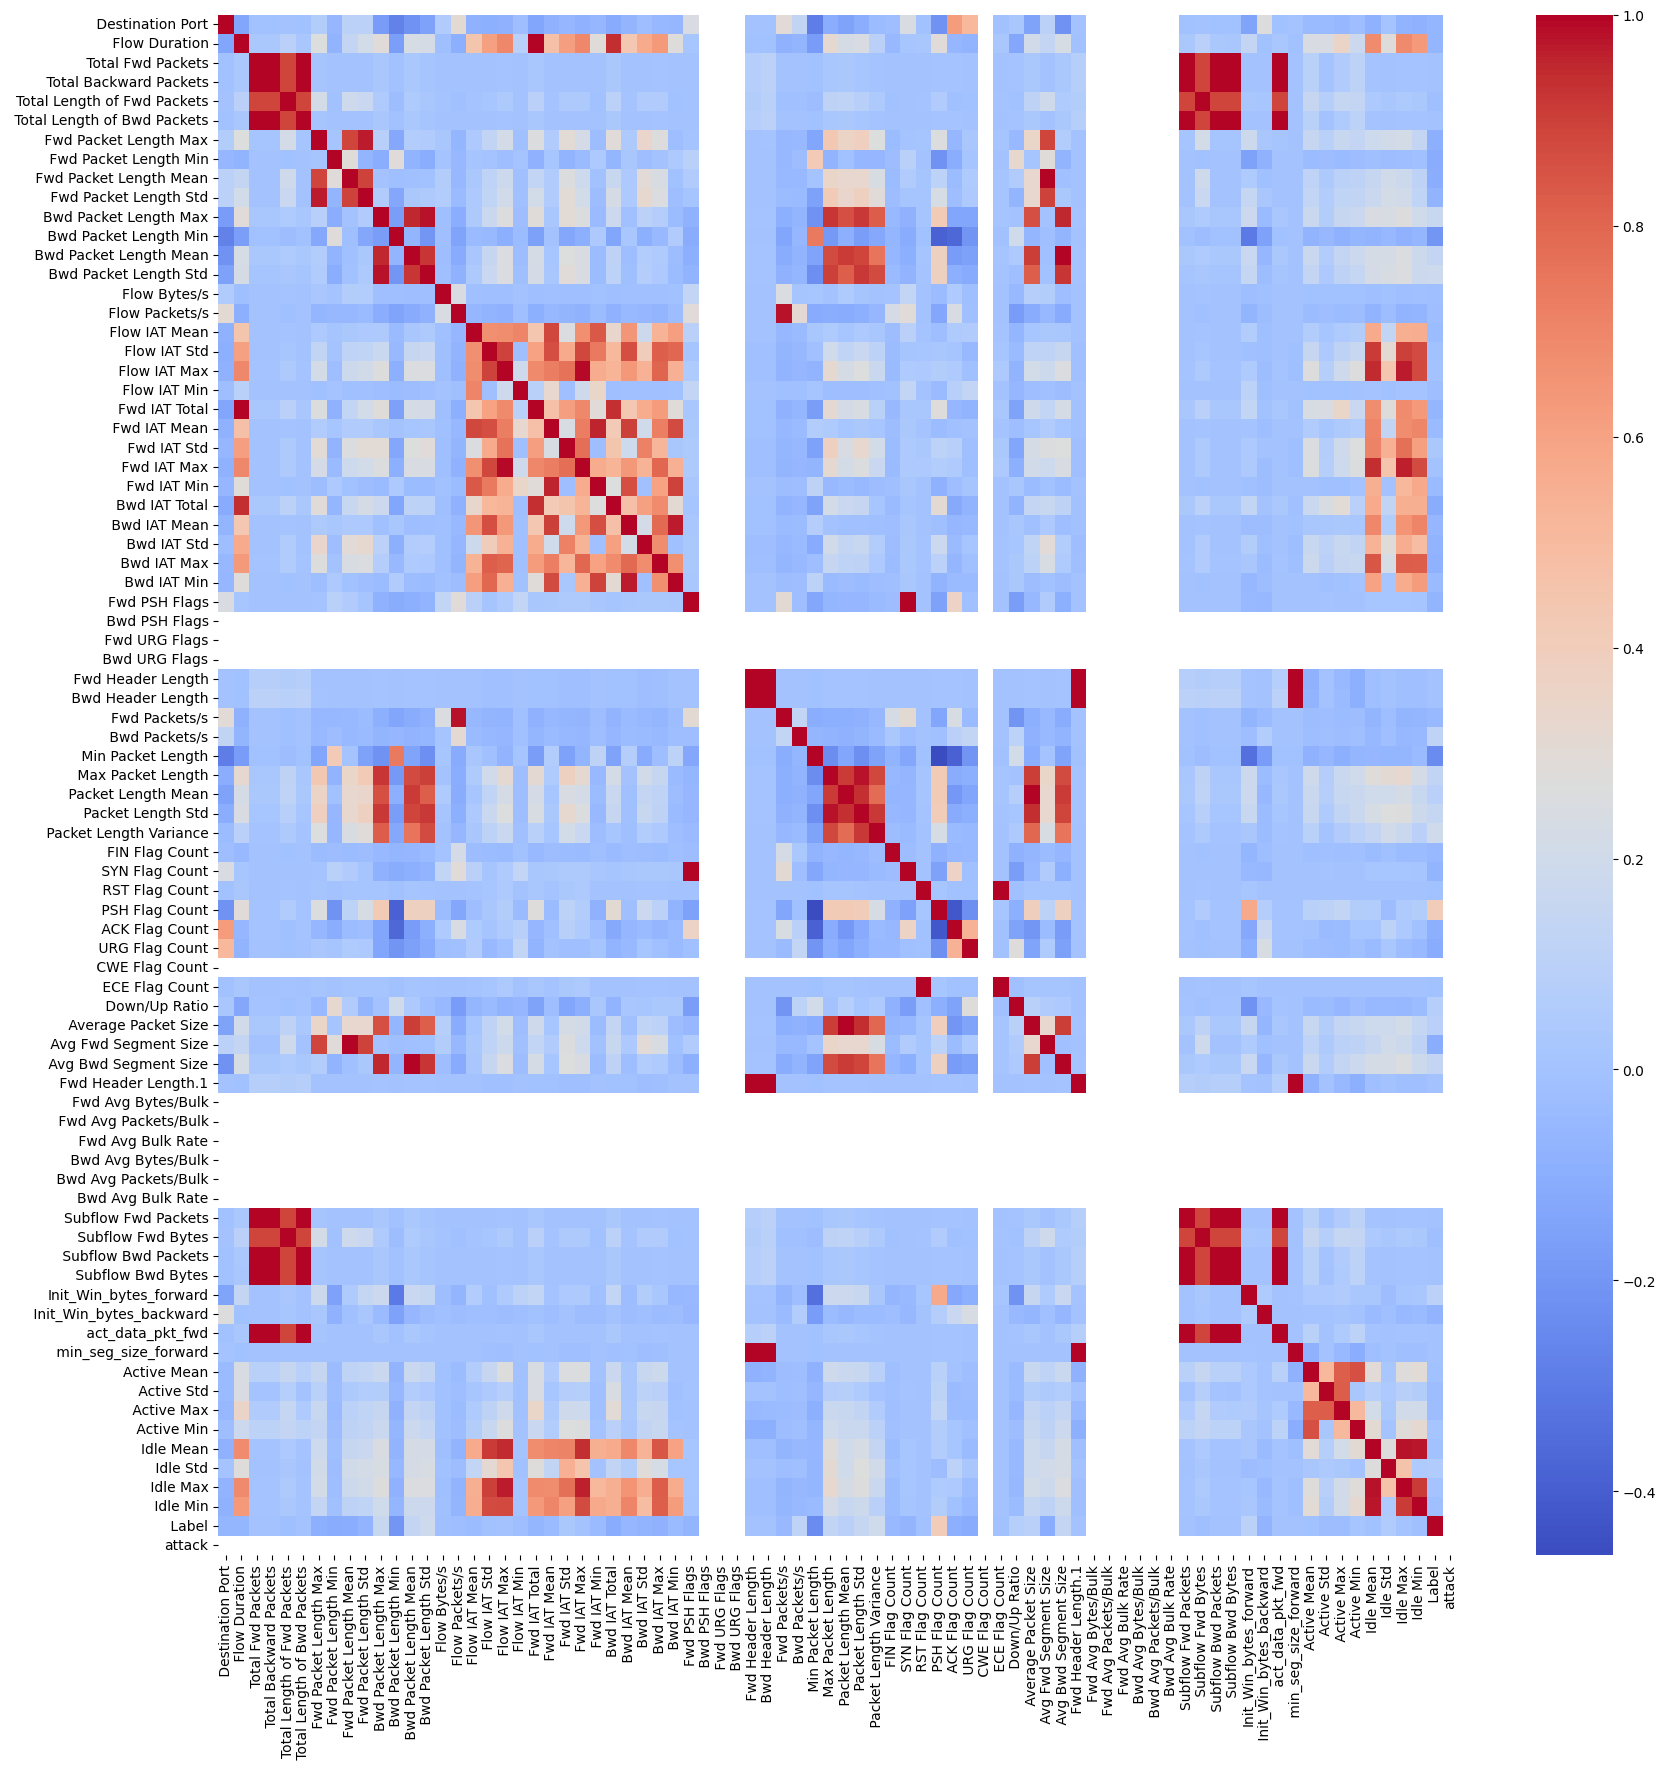

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(df[df['attack'] == 1].corr(), cmap='coolwarm')
plt.show()

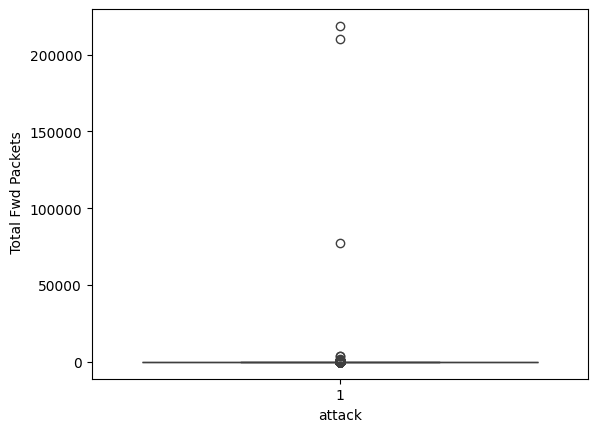

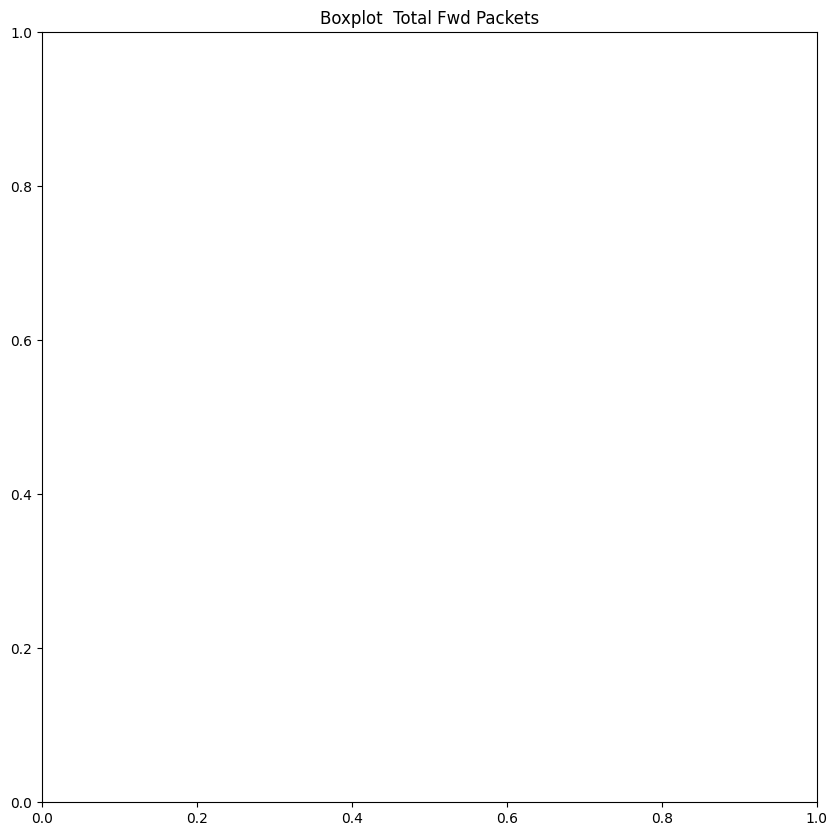

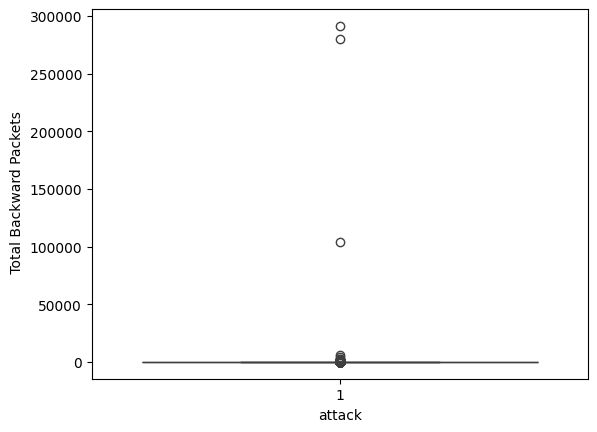

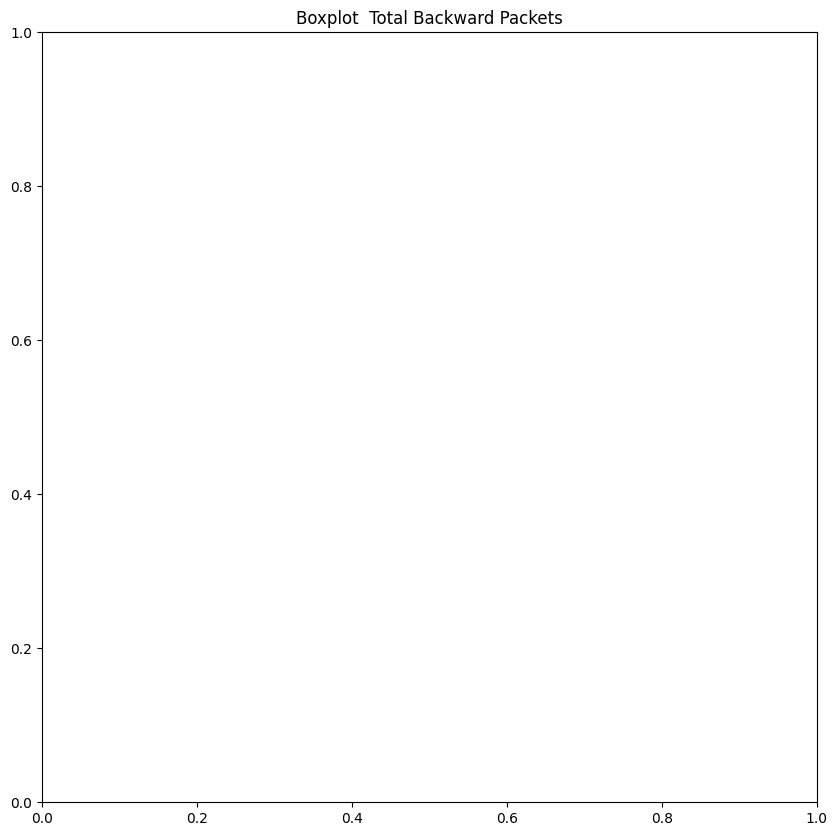

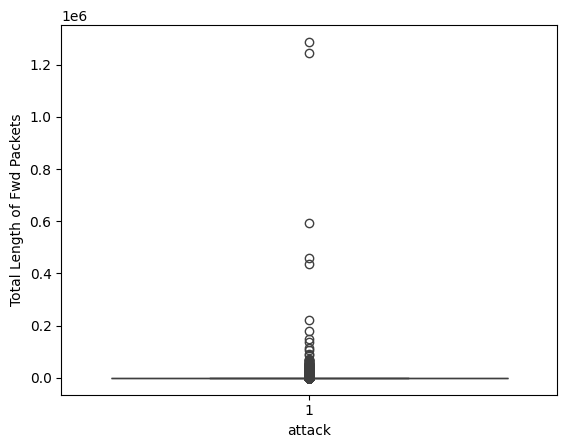

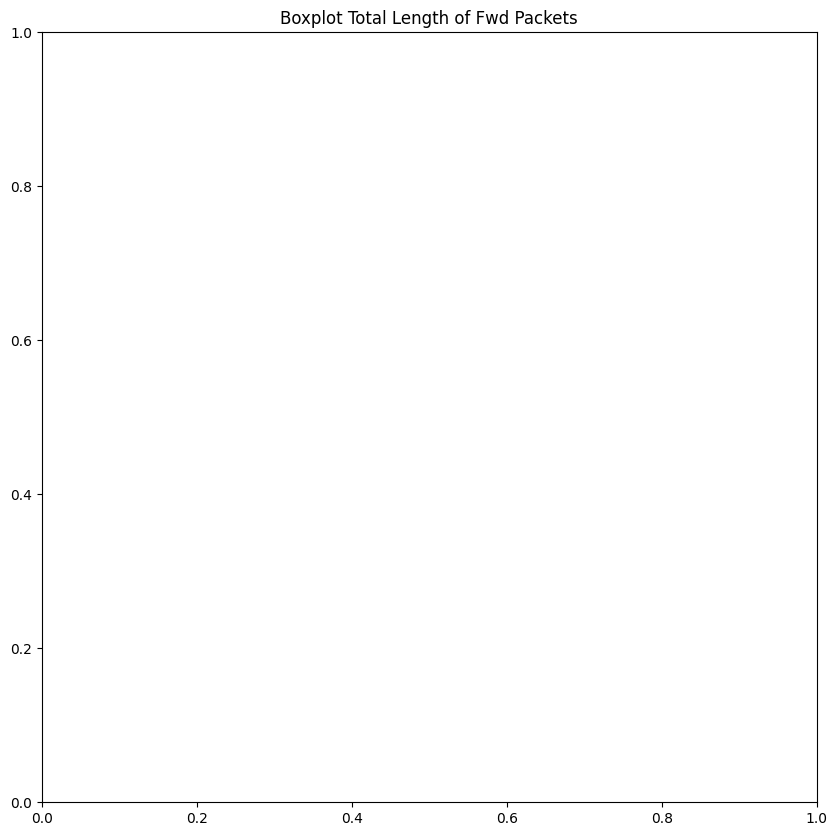

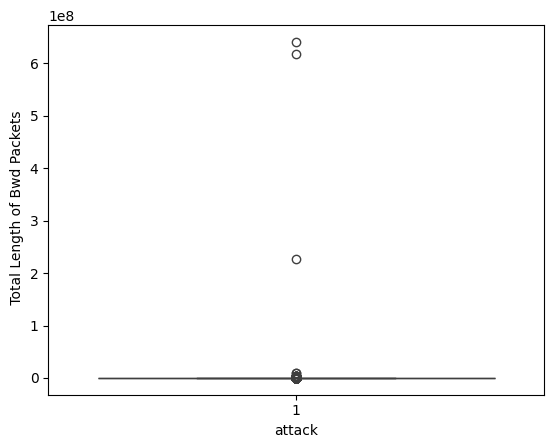

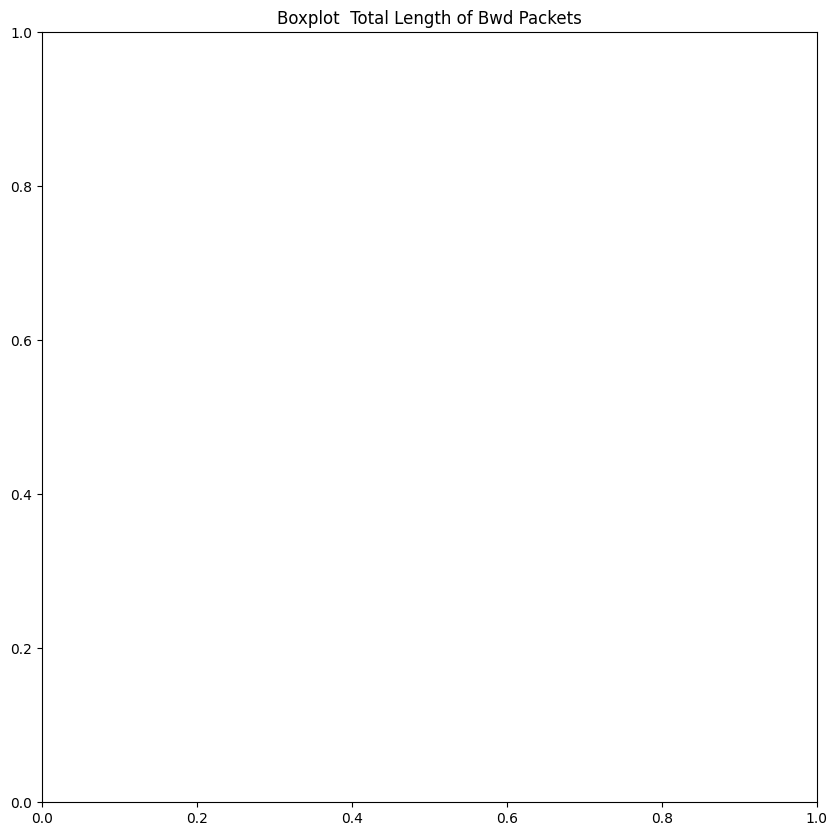

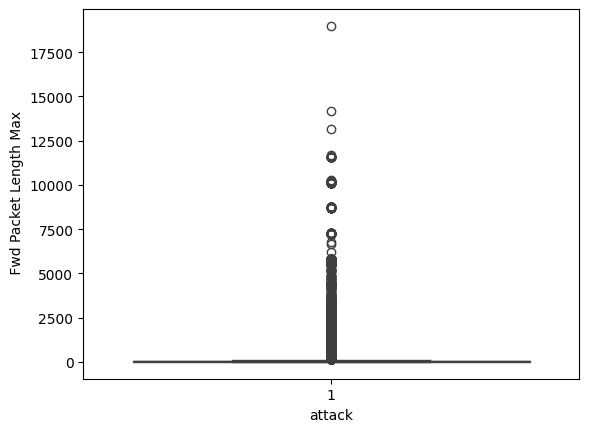

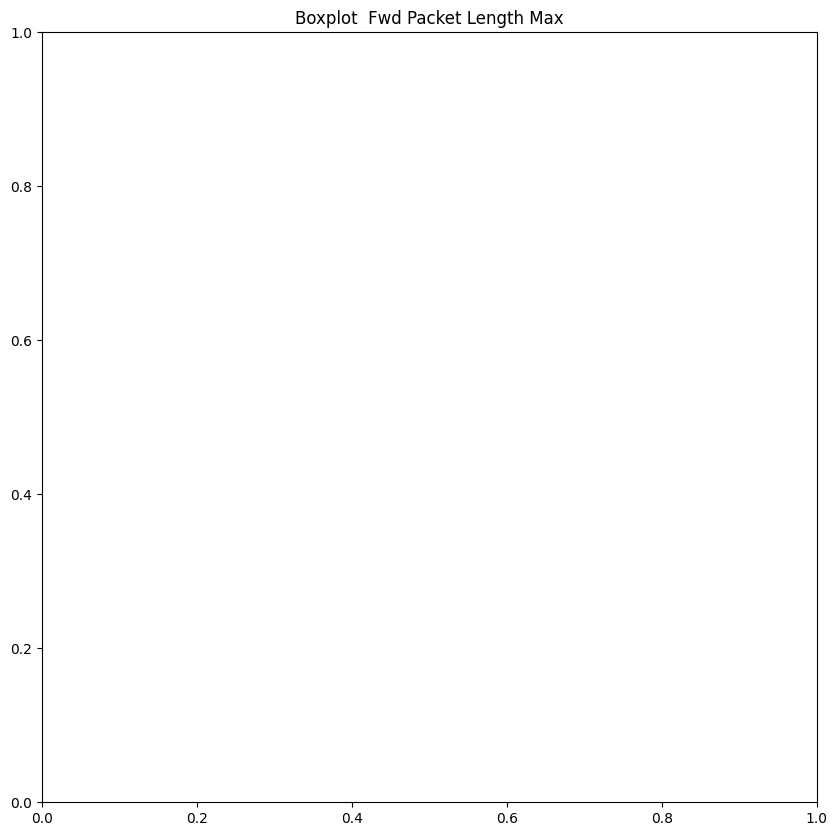

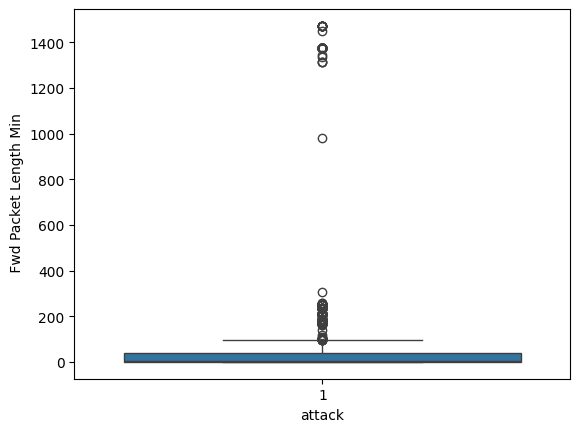

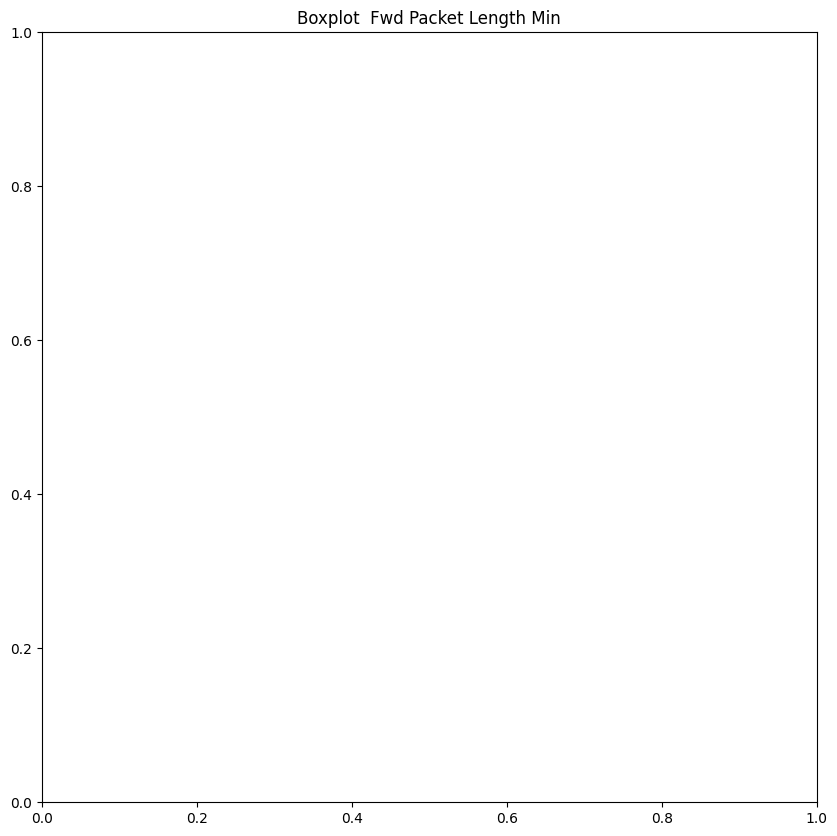

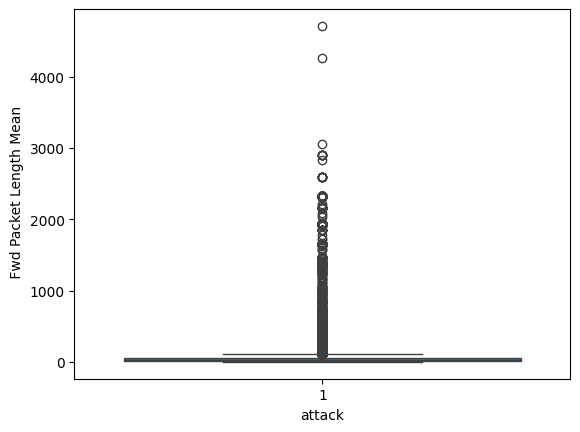

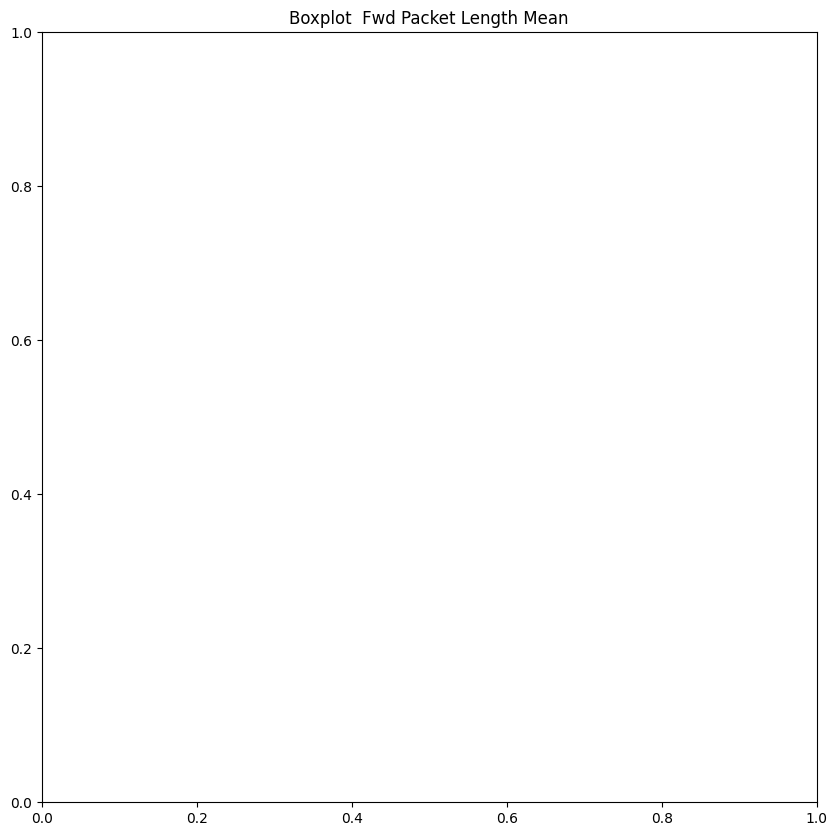

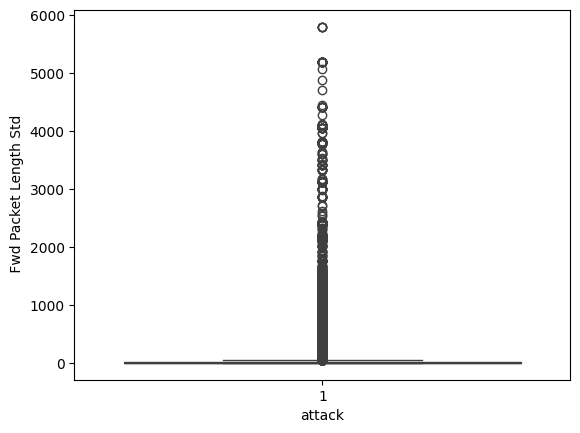

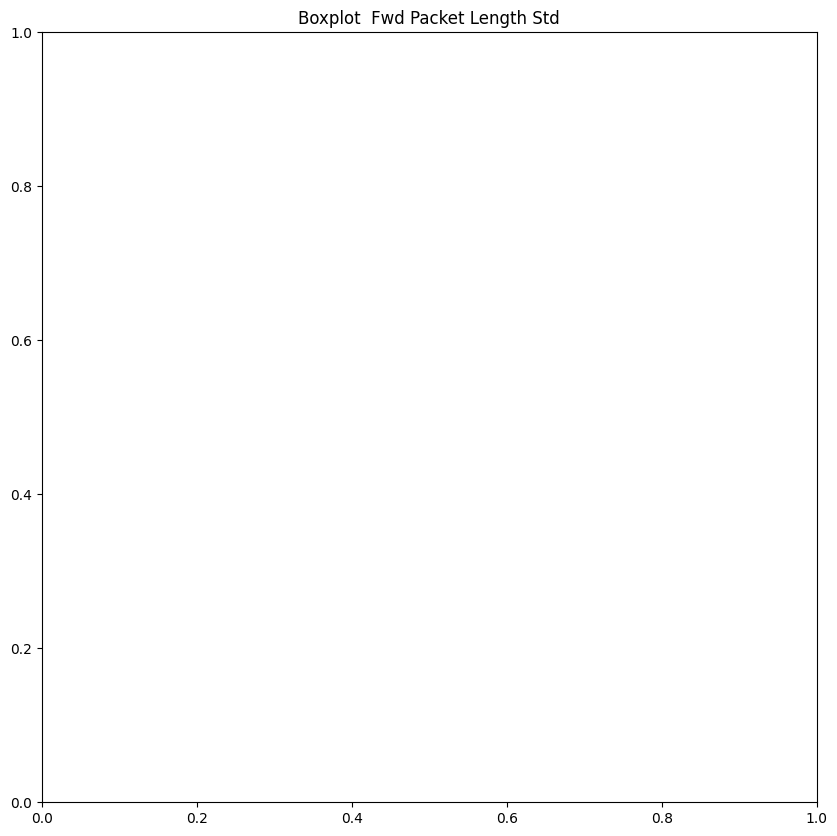

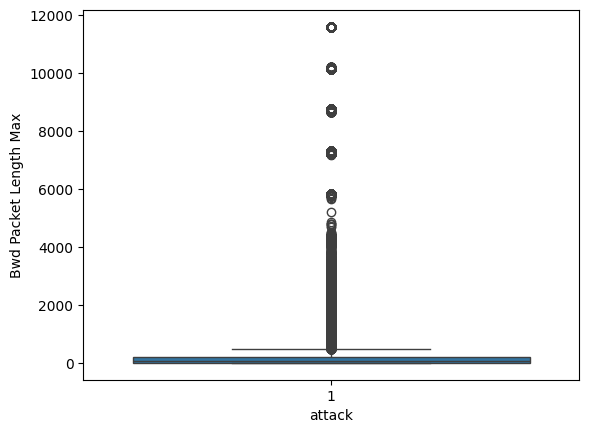

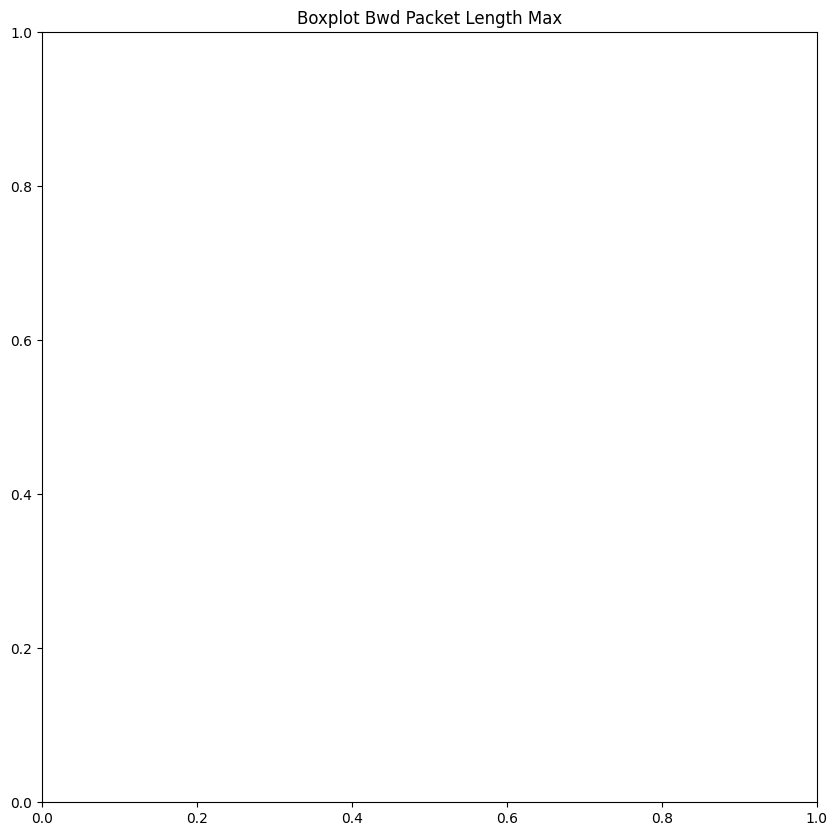

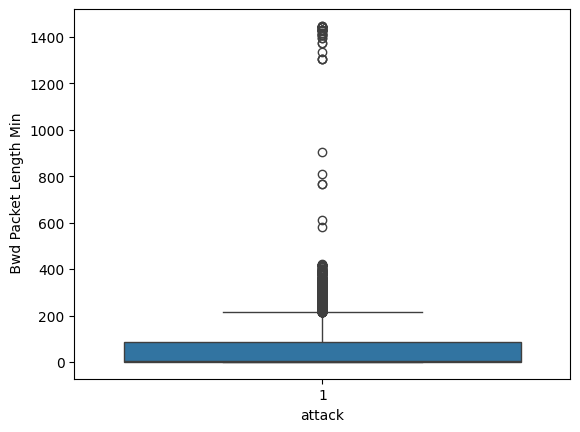

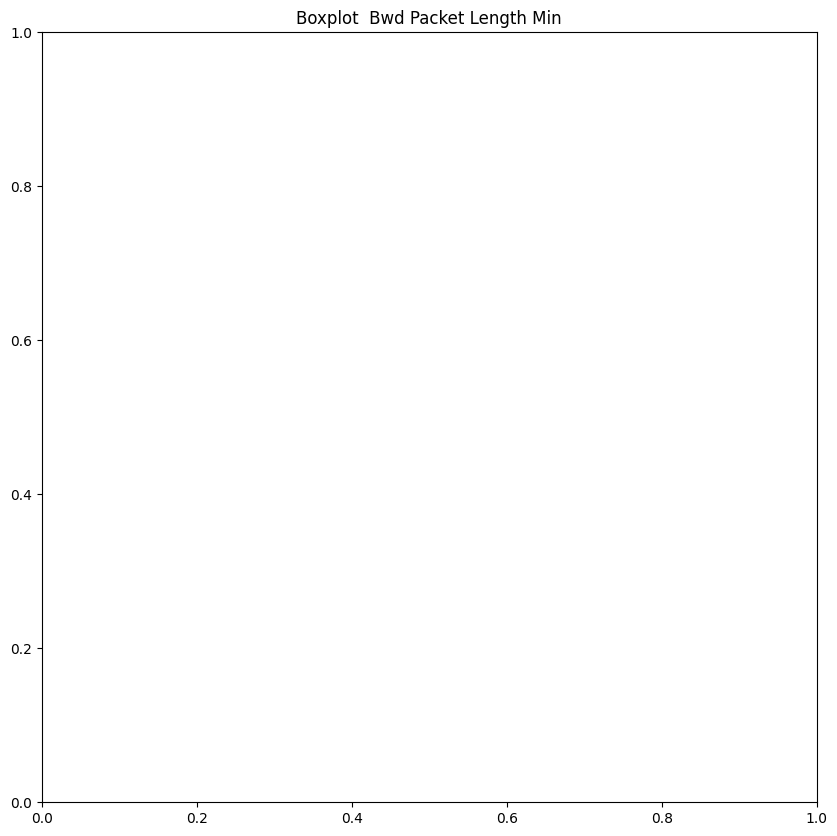

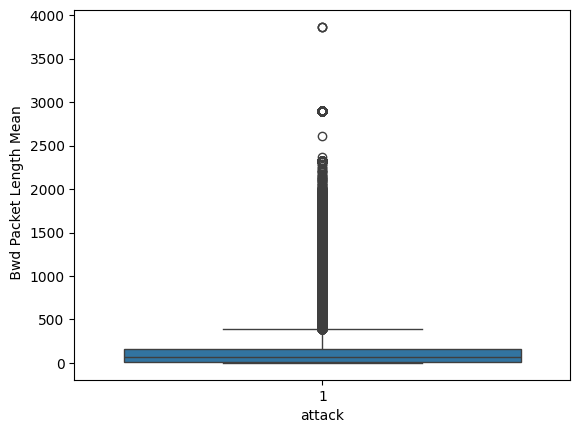

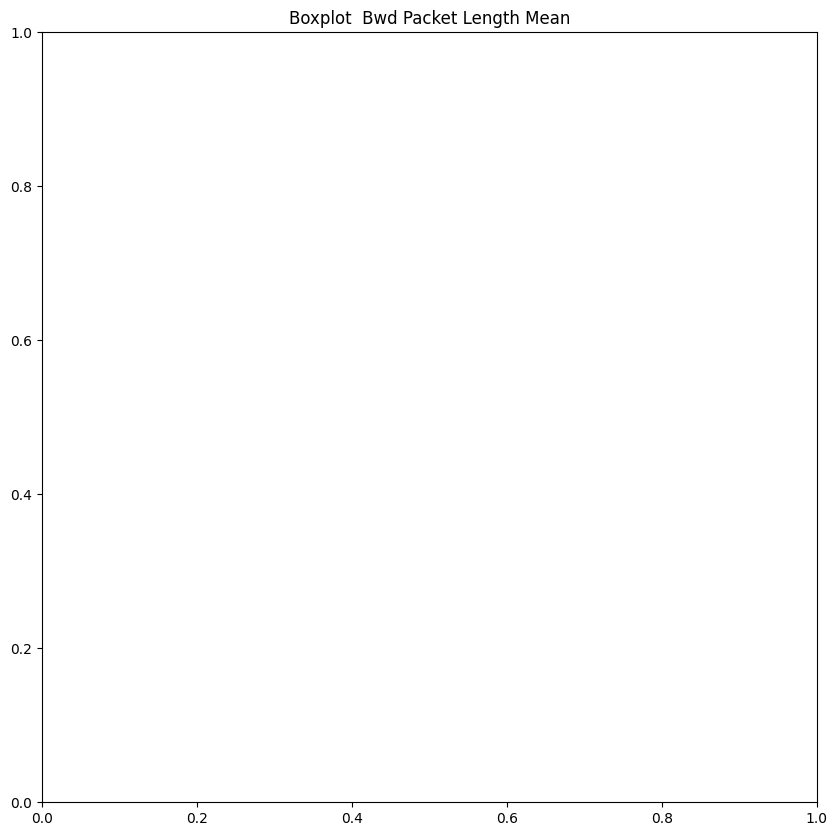

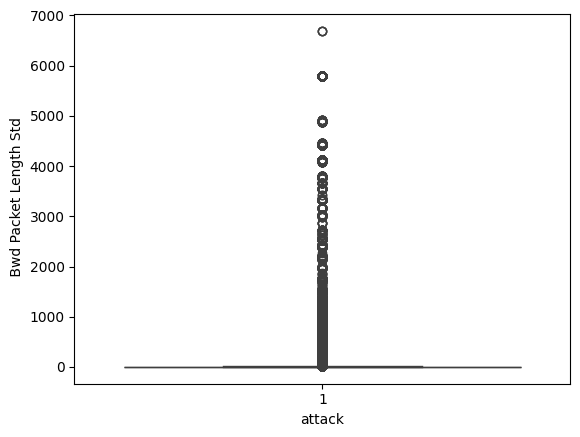

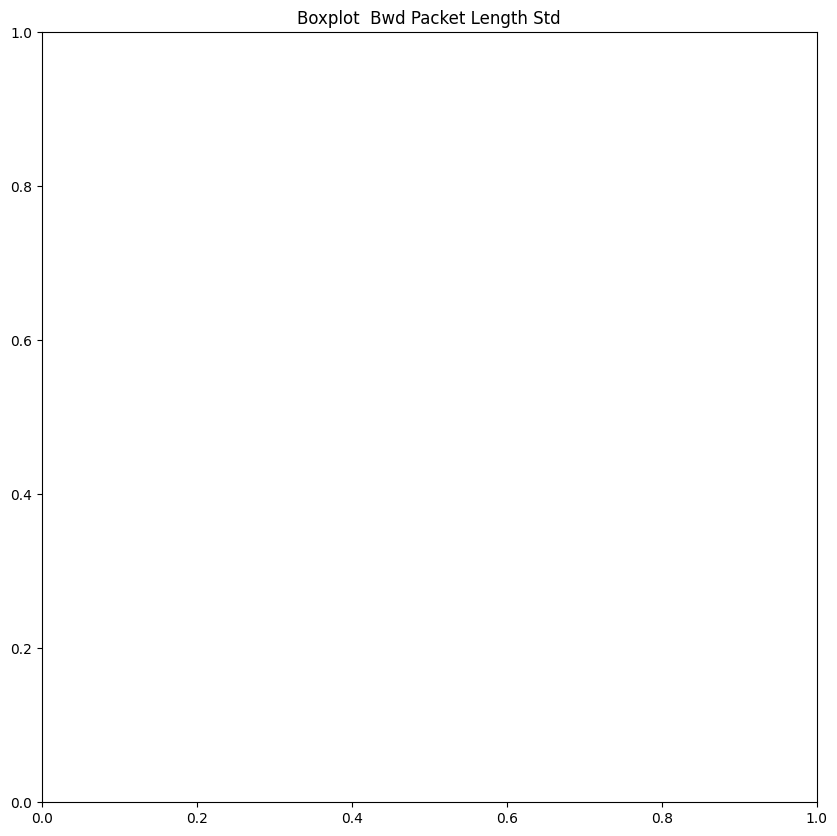

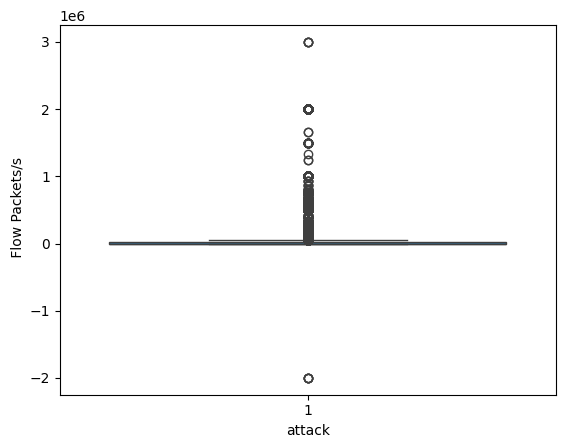

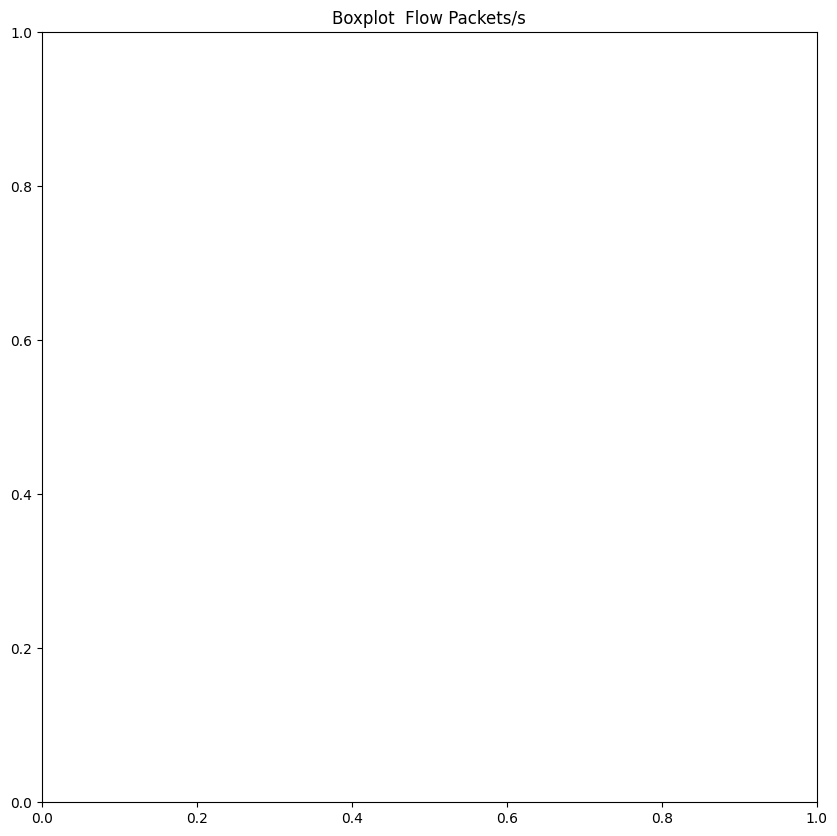

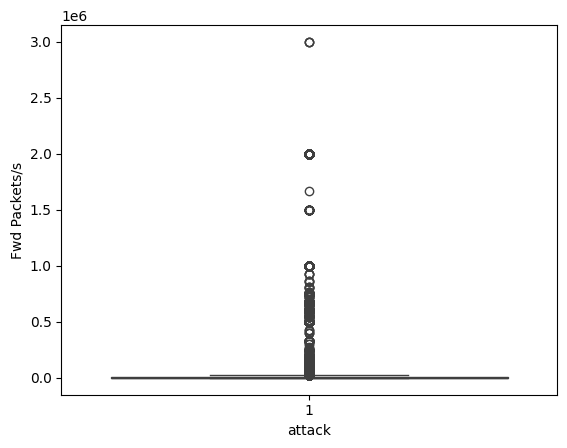

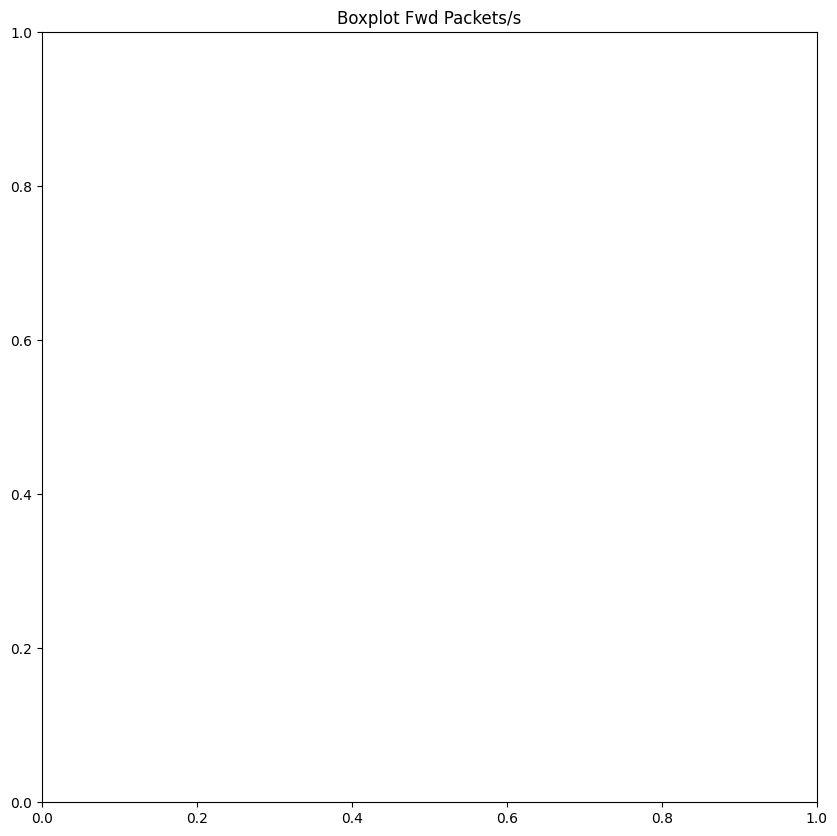

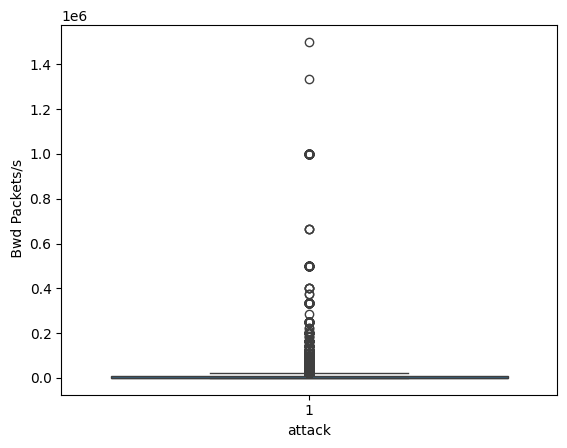

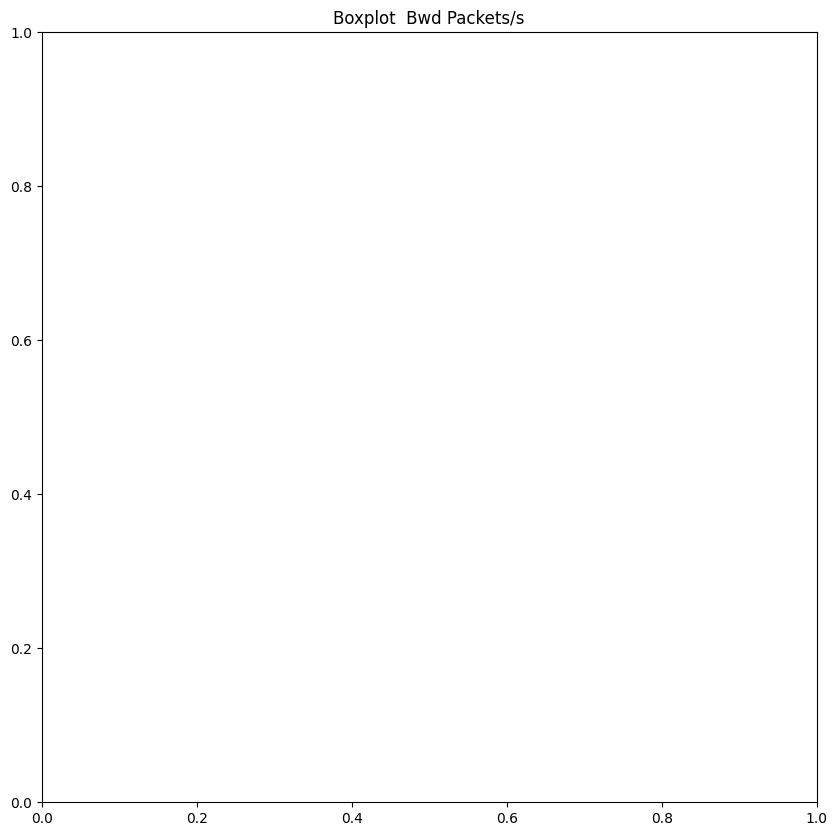

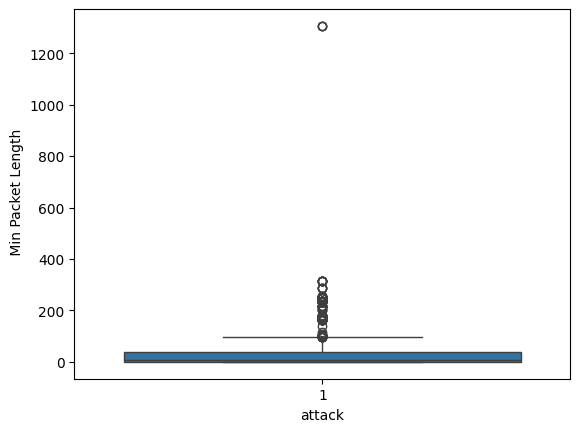

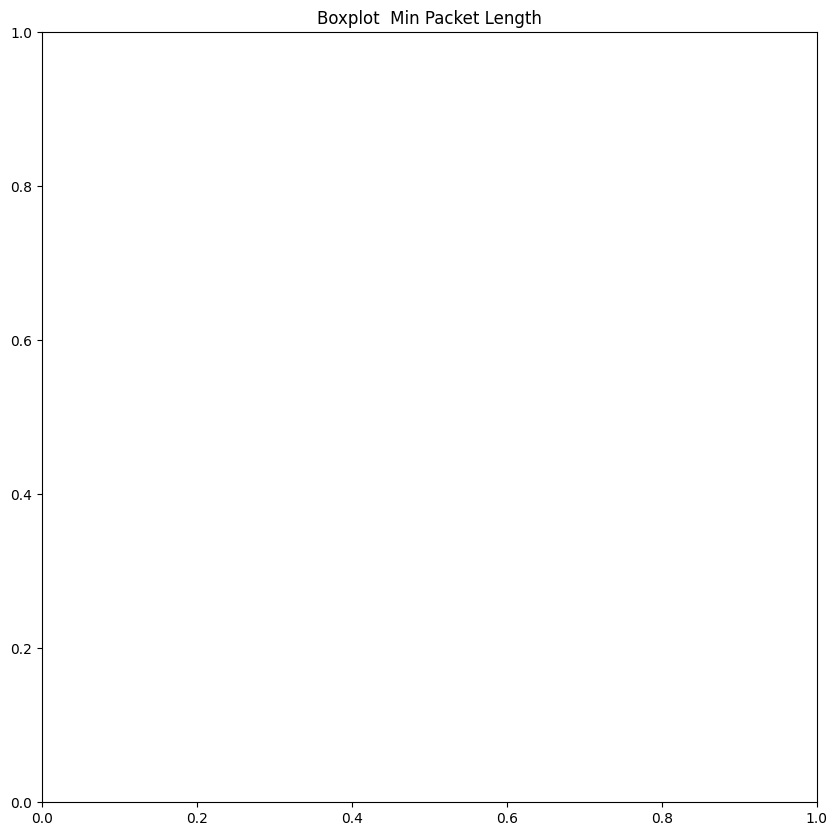

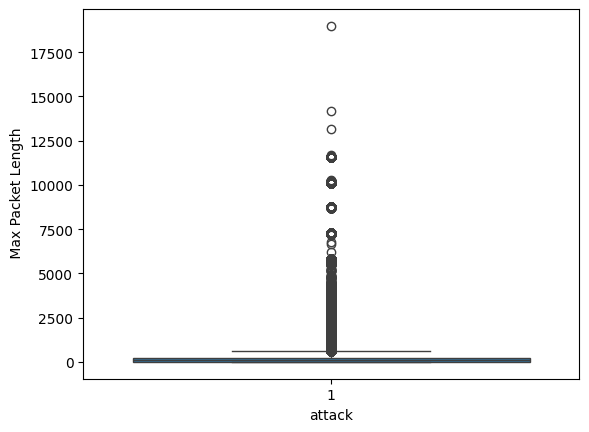

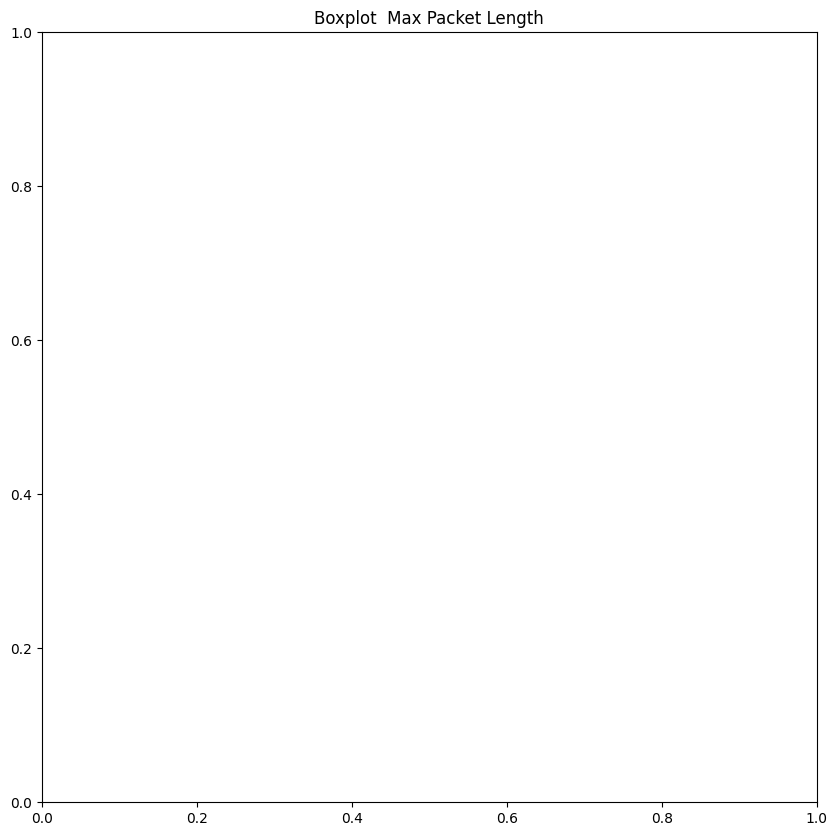

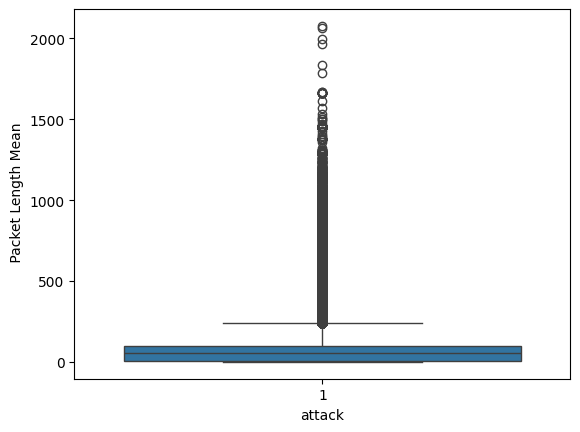

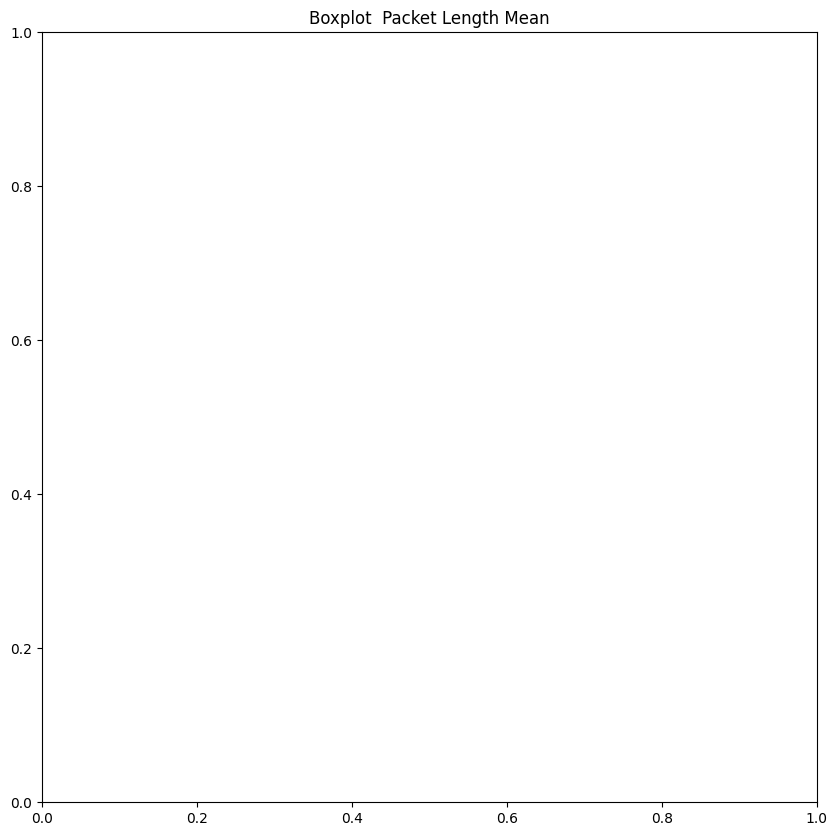

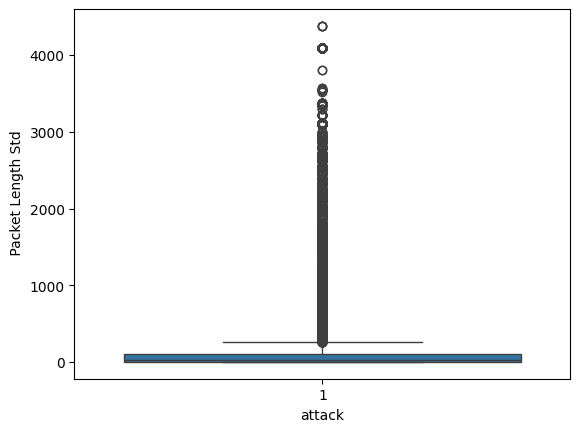

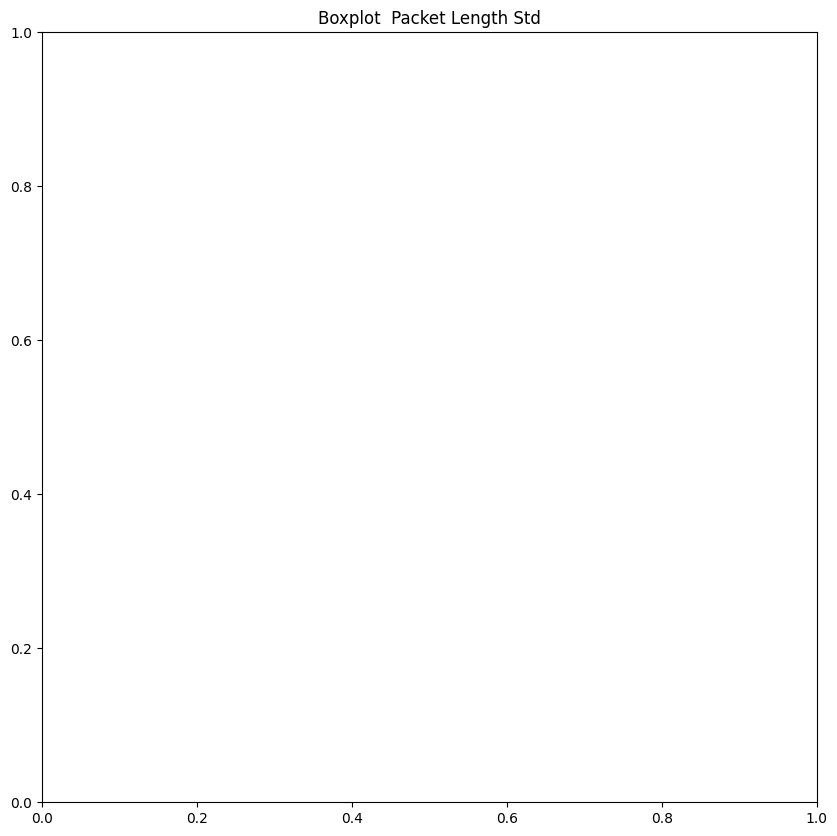

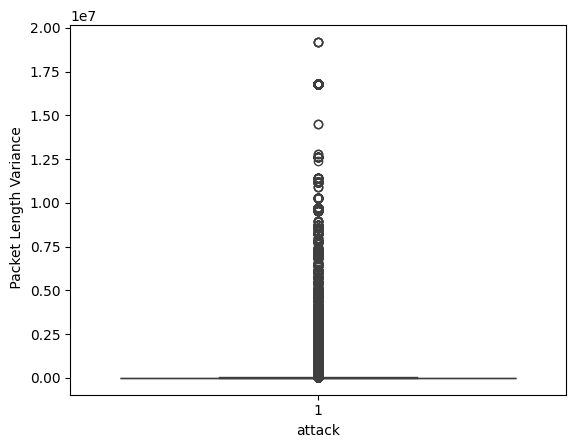

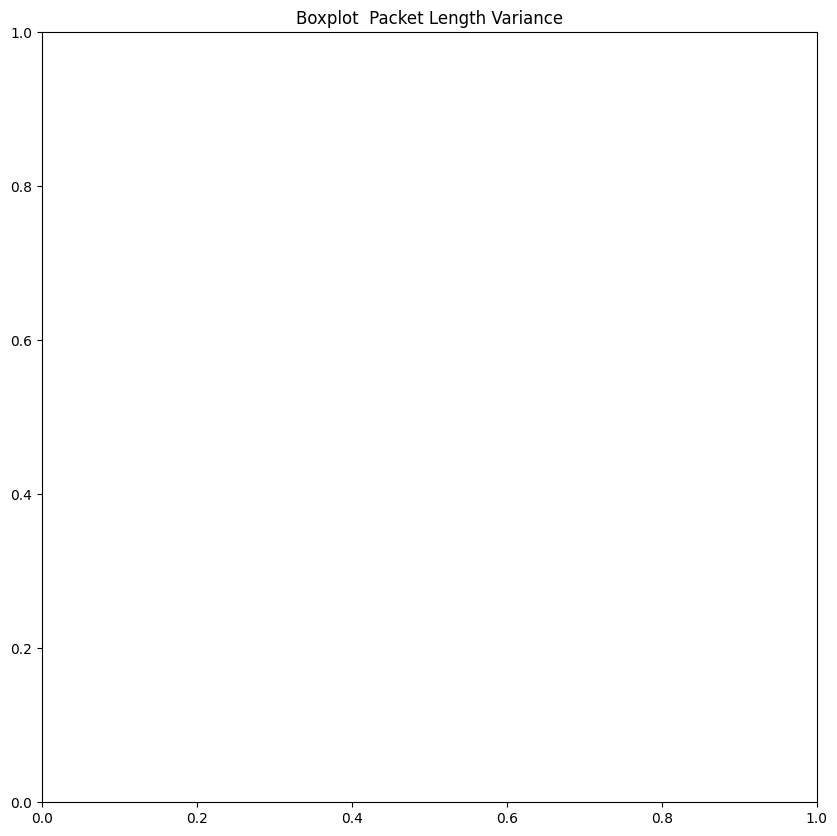

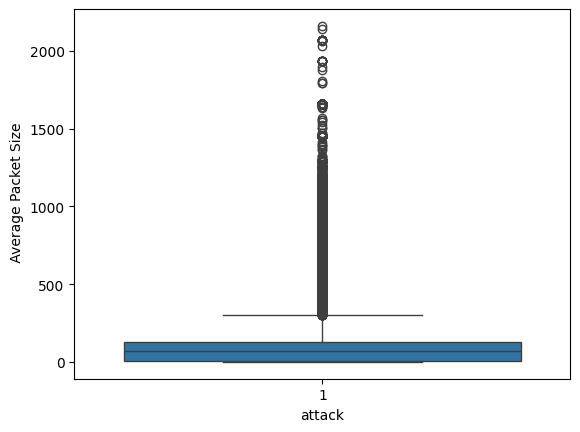

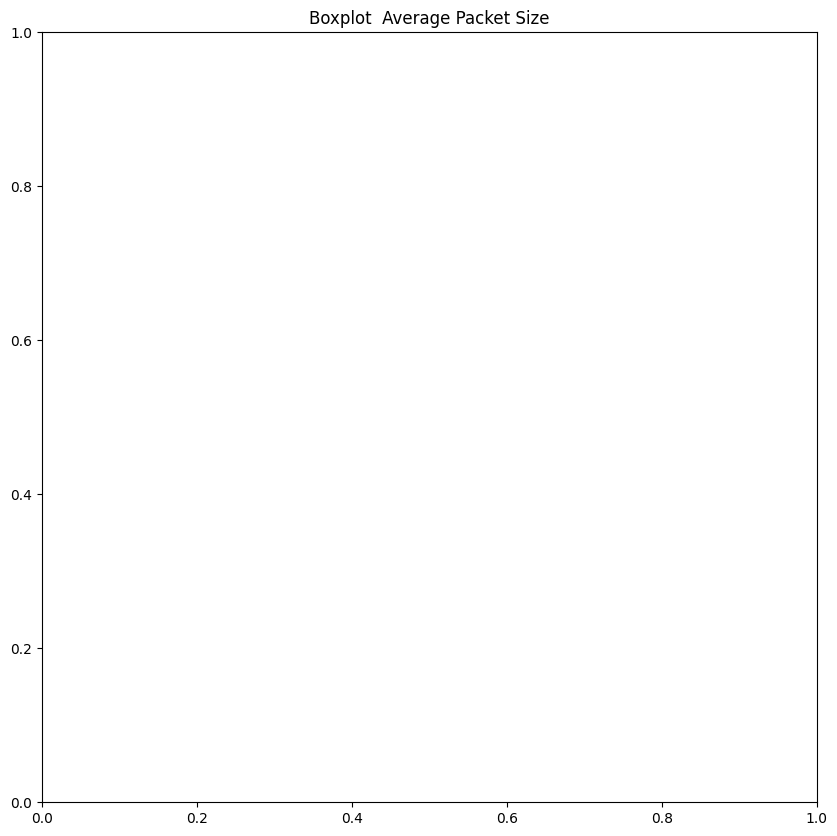

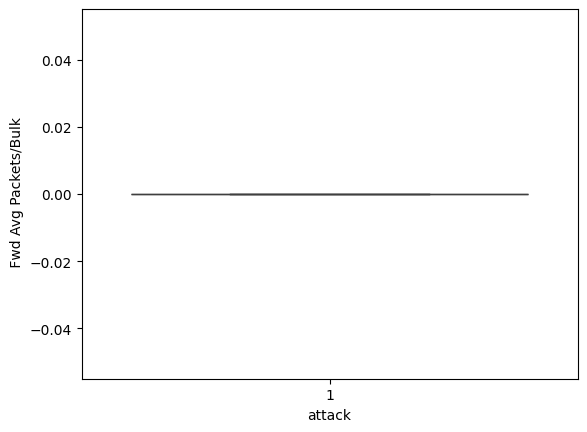

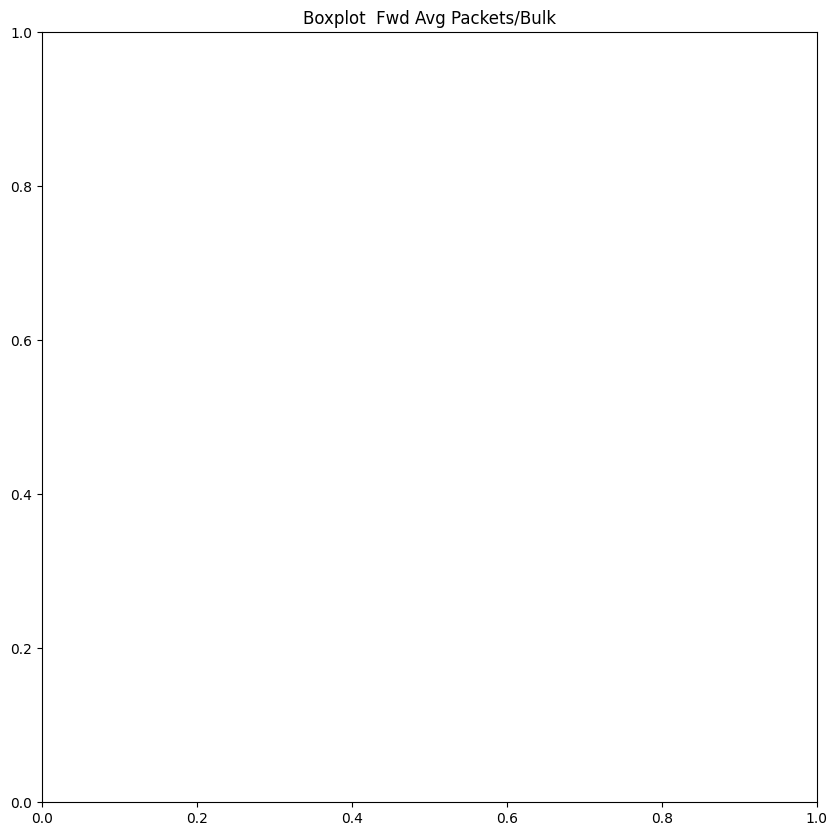

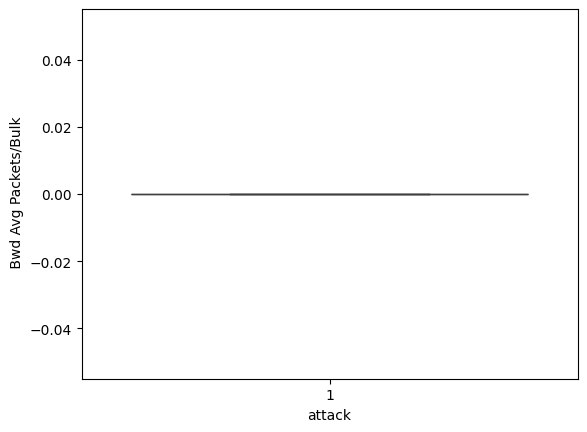

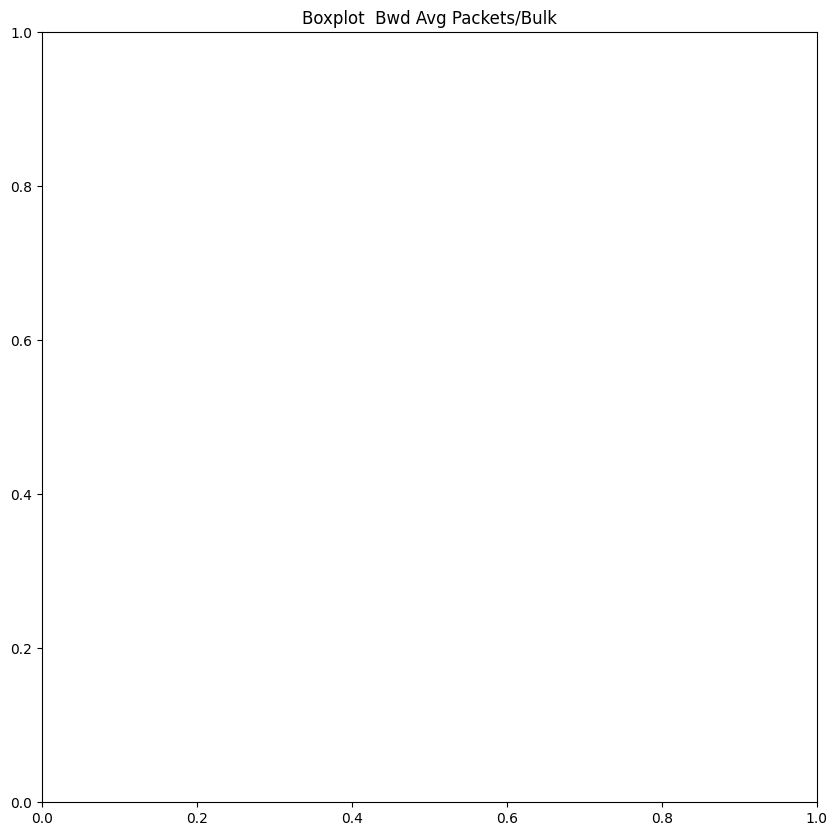

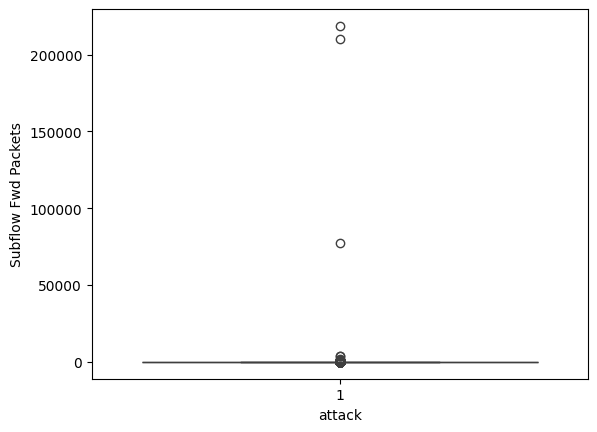

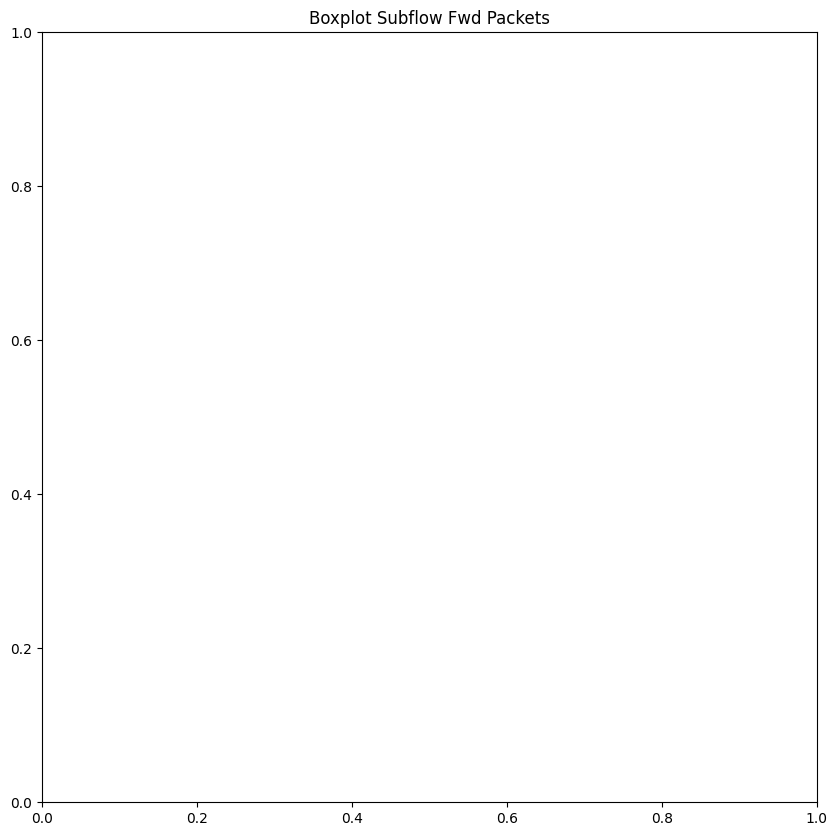

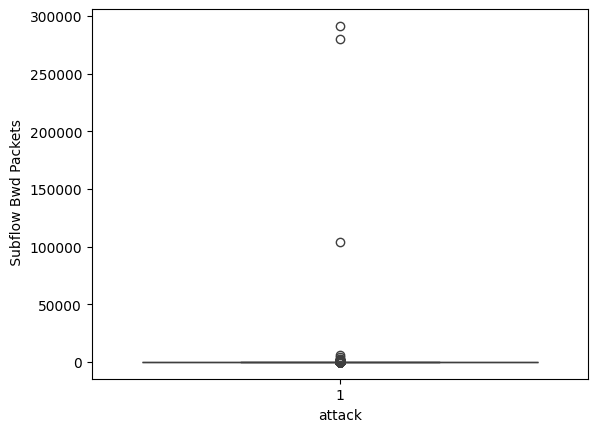

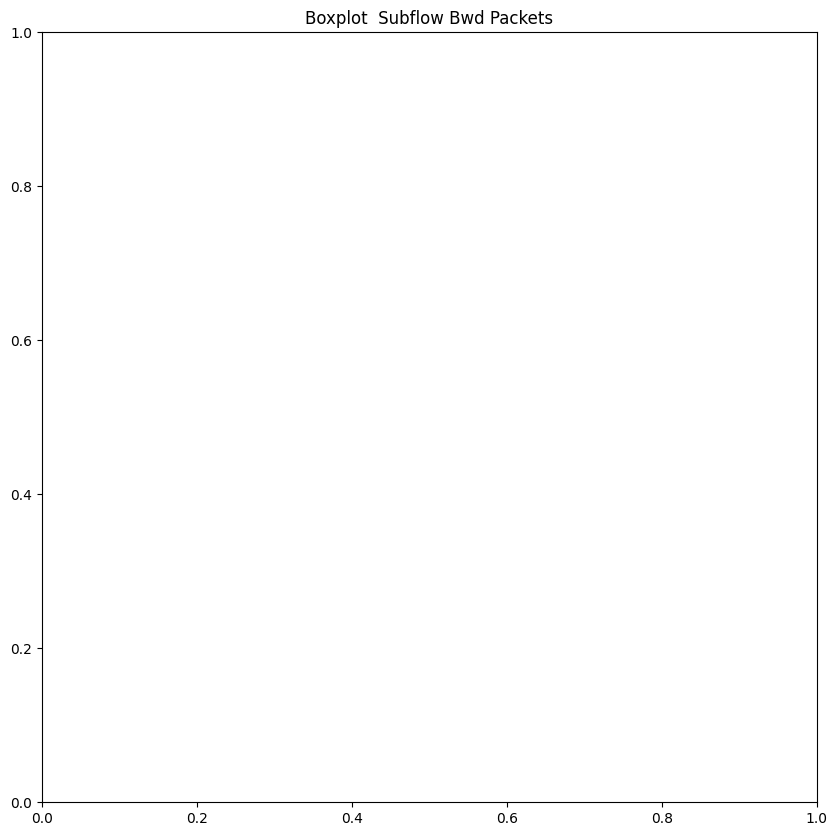

In [ ]:
for col in df.columns:
  if 'Packet' in str(col):
    # print(col)
    sns.boxplot(data=df, x='attack', y=col)
    plt.figure(figsize=(10,10))
    plt.title(f"Boxplot {col}")
    plt.show()

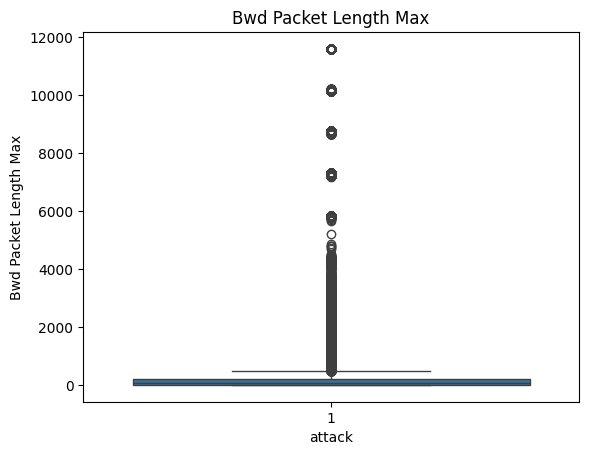

In [ ]:
sns.boxplot(data=df, x='attack', y='Bwd Packet Length Max')
plt.title('Bwd Packet Length Max')
plt.show()

In [46]:
df.groupby(' Label').size()

,0
Label,
BENIGN,87274
Bot,90
DDoS,5248
FTP-Patator,354
PortScan,6677
SSH-Patator,263
Web Attack � Brute Force,59
Web Attack � Sql Injection,3
Web Attack � XSS,32


In [53]:
packet_columns = []
for col in df.columns:
  if 'Packet' in str(col):
    packet_columns.append(col)

In [54]:
df.shape

(100000, 80)

In [58]:
# Split features and target
X = df.drop([' Label', 'attack'], axis=1)
# X = df[packet_columns].values
y = df[' Label'].values

In [59]:
X.shape, y.shape, X.max(), X.min()

((100000, 78),
 (100000,),
  Destination Port              6.553100e+04
  Flow Duration                 1.200000e+08
  Total Fwd Packets             1.737620e+05
  Total Backward Packets        2.283750e+05
 Total Length of Fwd Packets    6.770900e+05
                                    ...     
  Active Min                    7.140000e+07
 Idle Mean                      1.200000e+08
  Idle Std                      7.353239e+07
  Idle Max                      1.200000e+08
  Idle Min                      1.200000e+08
 Length: 78, dtype: float64,
  Destination Port              0.0
  Flow Duration                -1.0
  Total Fwd Packets             1.0
  Total Backward Packets        0.0
 Total Length of Fwd Packets    0.0
                               ... 
  Active Min                    0.0
 Idle Mean                      0.0
  Idle Std                      0.0
  Idle Max                      0.0
  Idle Min                      0.0
 Length: 78, dtype: float64)

In [57]:
#sklearn

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [47]:
y_pred = model.predict(X_test)

In [48]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.99865


Confusion Matrix:
[[17472     4     1     0     1     0     0     0     0]
 [    7     8     0     0     0     0     0     0     0]
 [    3     0  1031     0     0     0     0     0     0]
 [    2     0     0    78     0     0     0     0     0]
 [    1     0     0     0  1327     0     0     0     0]
 [    1     0     0     0     0    49     0     0     0]
 [    2     0     0     0     0     0     4     0     0]
 [    0     0     0     0     0     0     0     1     0]
 [    3     0     0     0     0     0     2     0     3]]


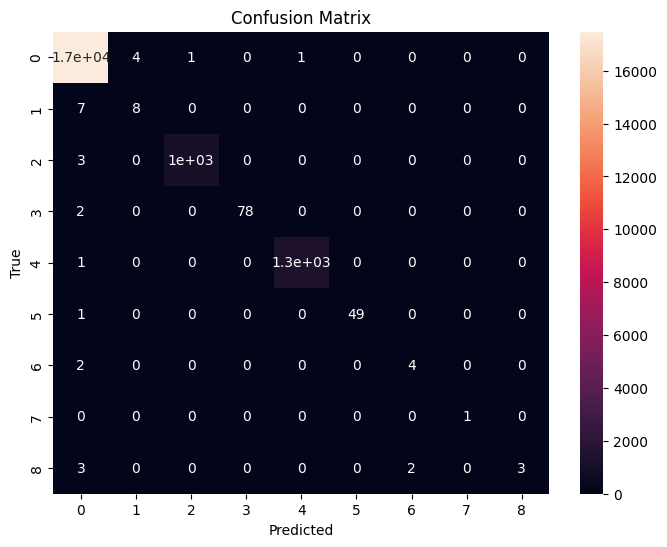

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [60]:
feature_importances = model.feature_importances_
features_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importances
})


In [61]:
features_df.sort_values('importance', ascending=False).head(10)

,feature,importance
42,Packet Length Variance,0.054696
54,Avg Bwd Segment Size,0.048079
52,Average Packet Size,0.045777
46,PSH Flag Count,0.042528
39,Max Packet Length,0.041420
41,Packet Length Std,0.040485
10,Bwd Packet Length Max,0.039352
12,Bwd Packet Length Mean,0.036600
63,Subflow Fwd Bytes,0.036291
6,Fwd Packet Length Max,0.033509


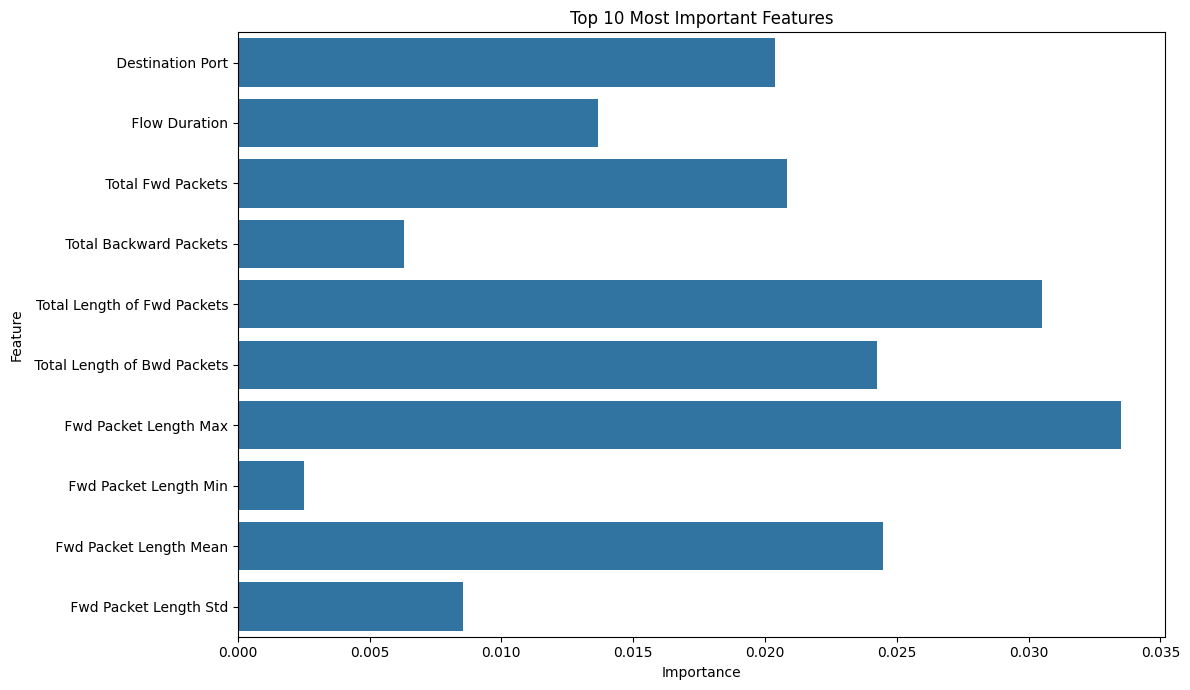

In [62]:
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=features_df.head(10))
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [ ]:
# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


In [ ]:
# Define the neural network
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model = SimpleNN(X.shape[1], hidden_dim=128, output_dim=len(np.unique(y)))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Epoch 1/10, Loss: 0.3455
Epoch 2/10, Loss: 0.0777
Epoch 3/10, Loss: 0.0607
Epoch 4/10, Loss: 0.0510
Epoch 5/10, Loss: 0.0441
Epoch 6/10, Loss: 0.0389
Epoch 7/10, Loss: 0.0342
Epoch 8/10, Loss: 0.0311
Epoch 9/10, Loss: 0.0281
Epoch 10/10, Loss: 0.0255


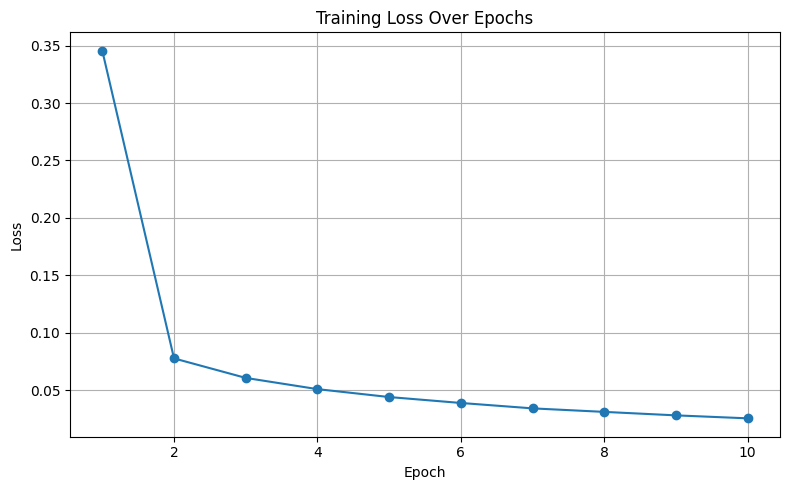

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3512
           1       0.00      0.00      0.00         2
           2       1.00      0.95      0.97       219
           3       0.85      1.00      0.92        11
           4       0.99      0.99      0.99       244
           5       1.00      0.50      0.67         8
           6       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         1

    accuracy                           0.99      4000
   macro avg       0.60      0.56      0.57      4000
weighted avg       0.99      0.99      0.99      4000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Training loop with loss tracking
epochs = 10
losses = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# Plot the loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.tolist())
        y_pred.extend(predicted.tolist())

print(classification_report(y_true, y_pred))